# `Материалы кафедры ММП факультета ВМК МГУ. Введение в глубокое обучение.`

# `Занятие 24. Практика обучения GAN`
## `Занятие провел: Оганов Александр (tg: @welmud)`
## `Материалы составили: Оганов Александр (tg: @welmud), Находнов Максим (nakhodnov17@gmail.com)`

### `Москва, Весенний семестр 2026`

Источники:

- **Generative Adversarial Networks**: [Ian J. Goodfellow et al., 2014](https://arxiv.org/abs/1406.2661), примерно 94 тысячи цитирований &ndash; работа в которой была предложена идея генеративно состязательных сетей

- [Небольшая история о том, как появилась идея GAN](https://www.technologyreview.com/2018/02/21/145289/)

- **DCGAN**: [Alec Radford et al., 2016](https://arxiv.org/abs/1511.06434), примерно 22 тысячи цитирований &ndash; улучшение GAN модели с помощью выявления принципов обучение и подбора правильной архитектуры; одна из первых моделей качественной генерации цветных изображений разрешением 64 пикселей

- [Обзор на область генеративных моделей от автора DCGAN на конференции ICLR 2026](https://iclr.cc/virtual/2026/test-of-time/10020471) &ndash; обзор идей, методов, истории их появлений и науке; **таймкод 35:40**, может потребоваться регистрация

- **Towards Principled Methods for Training Generative Adversarial Networks**: [Martin Arjovsky and Leon Bottou, 2017](https://arxiv.org/abs/1701.04862), примерно 3400 цитирований


- **Wasserstein GAN**: [Martin Arjovsky et al., 2017](https://arxiv.org/abs/1701.07875), примерно 22 тысячи цитирований &ndash; использование расстояния Вассерштейна для оценки похожести распределений (вместо KL дивергенции)

- **WGAN-GP**: [Ishaan Gulrajani et al., 2017](https://arxiv.org/abs/1704.00028), примерно 15 тысяч цитирований &ndash; появление gradient penalty для соблюдения необходимого условия модели критика

- **R3GAN**: [Yiwen Huang et al., 2025](https://arxiv.org/abs/2501.05441), примерно 100 цитат (май 2026) &ndash; современный подход к стабильному обучению GAN моделей с высоким разнообразием и теоретическими гарантиями

- **f-GAN**: [Sebastian Nowozin et al., 2016](https://arxiv.org/abs/1606.00709), примерно 2300 цитирований

- **About KL Divergences**: [Alan Chan et al., 2022](https://arxiv.org/abs/2107.08285), 61 цитирование

- **How to Train GAN**: [GitHub](https://github.com/soumith/ganhacks)

- **From GAN to WGAN**: [GitHub](https://lilianweng.github.io/posts/2017-08-20-gan/)

- **Разные реализации**: [GitHub](https://github.com/eriklindernoren/PyTorch-GAN/tree/master)

- [Greedification Operators for Policy Optimization: Investigating Forward and Reverse KL Divergences](https://jmlr.org/papers/volume23/21-054/21-054.pdf)


- [Часть материала основана на курсе "Глубокого обучения" ВМК МГУ](https://github.com/Dyakonov/DL/blob/47f2efbadfd15f8d0a5f5cb209386aba64326eb6/2020/DL2020_053gan_13n.pdf)

- [Часть материала основана на семинаре НИУ ВШЭ](https://github.com/nakhodnov17/HSE_DPO_DL/tree/40bee88bfae8c601f1068d8d70ad0d04078286dd/Seminars/Seminar%2007)

- [Часть материала основана на курсе "Глубокие генеративные модели" AIMasters](https://github.com/r-isachenko/2024-DGM-AIMasters-course/blob/5aa2879d9d4091cbed6b8d86900ee36e47489767)


[По ссылке](https://wandb.ai/nakhodnov17/mmp_practicum_spring_2024%7CSeminar%2011%7CWGAN-GP/runs/o7qnv1aq?nw=nwusernakhodnov17) можно посмотреть логи `wandb` для всех экспериментов.

<font color='OrangeRed'>**Важно:**</font> желательно использовать GPU, в ином случае модель будет учиться долго.

В этом ноутбуке вы познакомитесь с такими генеративными моделями, как генеративные состязательные сети (GAN). Каждая модель имеет свои сильные и слабые стороны, например, GAN генерирует качественные изображения, но имеет проблемы с разнообразием. Этот эффект называется коллапсированием мод (mode collapse). На практике важно понимать причины возникновения коллапсирования мод и как с этим бороться.

---

Для начала нам необходимо загрузить библиотеки. Также, мы установим режим вывода графиков в векторные форматы.

In [1]:
# !pip install ml_collections -q

In [2]:
import os
import time
import random

import wandb
from tqdm.notebook import tqdm

import numpy as np
import matplotlib_inline
import matplotlib.pyplot as plt
from ml_collections import ConfigDict
from scipy.stats import norm

import torch
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import MNIST

from torchvision.utils import make_grid
import torchvision.transforms as transforms

%matplotlib inline
# matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg') 
# комментарий выше для отображения легенд в pdf, если pdf не нужен, то лучше убрать комментарий 

Обучение генеративных моделей, особенно GAN, крайне стохастическое, поэтому мы особенно внимательно будем следить за воспроизводимостью.

In [3]:
def set_global_seed(seed: int) -> None:
    """
    Set global seed for reproducibility.
    """

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(42)

## Дивергенция

<font color='Orange'>**Вопрос:**</font> Как можно оценить близость двух вероятностных распределений? Какие способы вы знаете?

#### Ответ:

Далее будем использовать стандартные обозначения:

\begin{align}
 &\pi(x) \text{  - распределение данных,}\\
 &p(x \mid \mu, \sigma) \text{ - распределение, в котором мы обучаем параметры $\mu$, $\sigma$}.
\end{align}

В нашем примере $p(x \mid \mu, \sigma)$ &ndash; генеративная модель.

####
При оптимизации дивергенции Кульбака-Лейблера наблюдаются эффекты **mean-seeking**, **mode-seeking**, которые возникают при оптимизации **forward** и **reverse** дивергенции соответсвенно. Напоминим, что:


\begin{align}
 &\textbf{Forward - } \text{KL}(\pi(x) \| p(x \mid \mu, \sigma)), \\
 &\textbf{Backward - } \text{KL}(p(x \mid \mu, \sigma) \| \pi(x)).
\end{align}

Наша первая цель - воспроизвести эти эффекты на практике. Для этого мы постраемся смоделировать смесь распределения с помощью унимодального распределения, то есть наша генеративная модель будет менее выразительна, чем распределение данных. На практике такое происходит часто, например, распределение изображений достаточно сложное для моделирования нейронной сетью размером менее чем миллиард параметров. Для реализации смеси распределений и других вероятностных объектов, будем использовать модуль `torch.distributions`.

В `torch.distributions` реализованы все стандартные распределения, подсчет KL-дивергенции, сэмплирование случайных величин `.sample()` и дифференцируемое по параметрам сэмплирование случайных величин `.rsample()` (не для всех распределений это возможно). Много чего реализовано в очень удобном формате, например, смеси распределений и вычисления скор-функции.

Подробнее можно почитать [в документации](https://pytorch.org/docs/stable/distributions.html).

Чтобы задать нормальное распределение, нам достаточно воспользоваться классом `torch.distributions.Normal`.

In [4]:
single_gaussian = torch.distributions.Normal(
    loc=torch.tensor(0.),
    scale=torch.tensor(1.)
)

Зададим распределение данных, которое будем моделировать смесью нормальных распределений.

\begin{align}
&\pi(x) = 0.8 p_1(x) + 0.2 p_2(x)\\
&p_1(x) = \mathcal{N}(x \mid -2, \frac{1}{4})\\
&p_2(x) = \mathcal{N}(x \mid 2, \frac{1}{4})\\
\end{align}

In [5]:
mixture_gaussian = torch.distributions.MixtureSameFamily(
    mixture_distribution=torch.distributions.Categorical(probs=torch.tensor([0.8, 0.2])),
    component_distribution=torch.distributions.Normal(
        loc=torch.tensor([-2., 2.]),
        scale=torch.tensor([0.5, 0.5])
    )
)

In [6]:
@torch.no_grad()
def plot_distributions(X, real_log_prob, model_log_prob=None, title=None, ax=None):
    res1 = real_log_prob(X).exp()
    if model_log_prob is not None:
        res2 = model_log_prob(X).exp()

    if ax is None:
        (fig, ax), show = plt.subplots(1, 1, figsize=(6, 4)), True
    else:
        show = False

    ax.plot(X.numpy(), res1.numpy(), color='b', linewidth=3, label=r'$\pi(\mathbf{x})$')
    ax.fill_between(X.numpy(), np.zeros_like(X.numpy()), res1.numpy(),  color='b', alpha=0.2)

    if model_log_prob is not None:
        ax.plot(X.numpy(), res2.numpy(), 'g', linewidth=3, label=r'$p(\mathbf{x} | \mu, \sigma)$')
        ax.fill_between(X.numpy(), np.zeros_like(X.numpy()), res2.numpy(),  color='g', alpha=0.2)

    if title is not None:
        ax.set_title(title)

    ax.legend()
    ax.grid(True)
    ax.set_xlabel('support')

    if show:
        fig.tight_layout()
        plt.show()

Визуализируем плотности вероятностей соотвествующих распределений.

In [7]:
X = torch.linspace(-6, 6, 500, dtype=torch.float32)

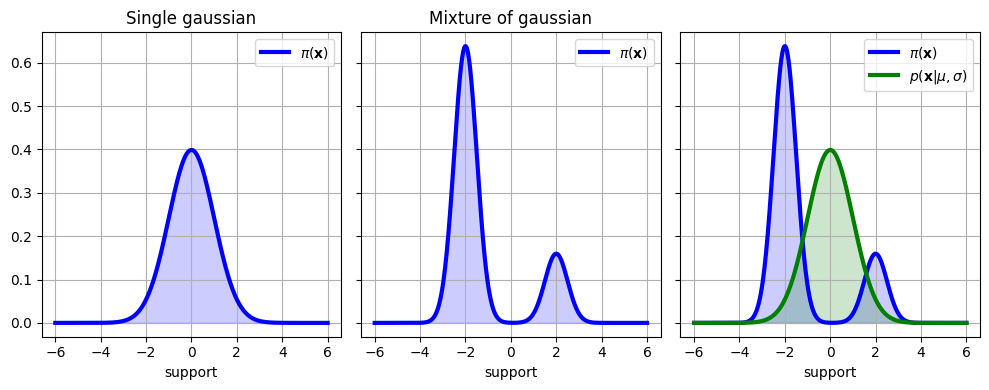

In [8]:
fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(10, 4))

plot_distributions(X, single_gaussian.log_prob, title='Single gaussian', ax=ax[0])
plot_distributions(X, mixture_gaussian.log_prob, title='Mixture of gaussian', ax=ax[1])
plot_distributions(X, mixture_gaussian.log_prob, single_gaussian.log_prob, ax=ax[2])

plt.tight_layout()

Мы рассмотрим **Forward** и **Reverse** KL-дивергенцию и дивергенцию Йенсена &ndash; Шеннона.

\begin{align}
&\text{KL}(\pi || p) = \int \pi(x) \log \frac{\pi(x)}{p(x)}dx, \\
&\text{KL}(p || \pi) = \int p(x) \log \frac{p(x)}{\pi(x)}dx, \\
&\text{JSD}(\pi || p) = \frac{1}{2} \Bigg[ \text{KL}\Big(\pi(x) || \frac{\pi(x) + p(x)}{2}\Big) + \text{KL}\Big(p(x) || \frac{\pi(x) + p(x)}{2}\Big) \Bigg].
\end{align}

Мы параметризуем распределение $p$ гауссианой и будем обучать ее параметры.

In [9]:
def KLD(X, log_prob1, log_prob2):
    dt = (X.max() - X.min()) / len(X)
    return (log_prob1(X).exp() * (log_prob1(X) - log_prob2(X))).sum() * dt

def JSD(X, log_prob1, log_prob2):
    def log_prob_mean(x):
        prob_mean = (log_prob1(x).exp() + log_prob2(x).exp()) / 2.0
        return prob_mean.log()

    return (KLD(X, log_prob1, log_prob_mean) + KLD(X, log_prob2, log_prob_mean)) / 2.0

In [10]:
def get_trainable_gaussian(mu=-1.0, sigma=0.5):
    mu = torch.tensor(mu, requires_grad=True, dtype=torch.double)
    sigma = torch.tensor(sigma, requires_grad=True, dtype=torch.double)

    single_gaussian = torch.distributions.Normal(mu, sigma)
    optimizer = torch.optim.SGD([mu, sigma], lr=0.03)

    return single_gaussian, optimizer

In [11]:
forward_KL_loss_fn = lambda X, real_log_prob, model_log_prob: KLD(X, real_log_prob, model_log_prob)
reverse_KL_loss_fn = lambda X, real_log_prob, model_log_prob: KLD(X, model_log_prob, real_log_prob)
JSD_loss_fn = lambda X, real_log_prob, model_log_prob: JSD(X, real_log_prob, model_log_prob)

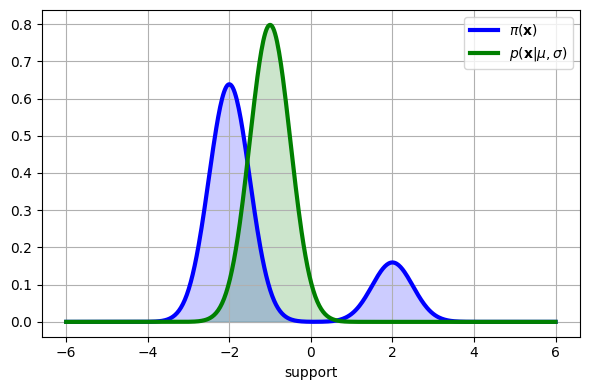

In [12]:
single_gaussian, _ = get_trainable_gaussian()

plot_distributions(X, mixture_gaussian.log_prob, single_gaussian.log_prob)

Для обучения напишем простой цикл обучения.

In [13]:
def solve_task(optimizer, loss_fn, real_log_prob, model_log_prob, epochs, verbose=True, freq=10):
    n_plots = (epochs // freq) * verbose + 2
    n_rows, n_cols = (n_plots - 1) // 3 + 1, 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2.5 * n_rows), sharex=True, sharey=True)
    axes = axes.reshape(-1)

    plot_distributions(X, real_log_prob, model_log_prob, title=f'Initialization', ax=axes[0])

    for epoch in range(epochs):
        optimizer.zero_grad()

        loss = loss_fn(X, real_log_prob, model_log_prob)
        loss.backward()
        optimizer.step()

        if verbose and epoch % freq == 0:
            plot_distributions(
                X, real_log_prob, model_log_prob,
                title=f'Step: {epoch}, loss: {loss:.2f}', ax=axes[epoch // 10 + 1]
            )

    plot_distributions(X, real_log_prob, model_log_prob, title=f'Final, loss: {loss:.2f}', ax=axes[-1])

    fig.tight_layout()
    plt.show()

Оптимизация forward дивергенции.

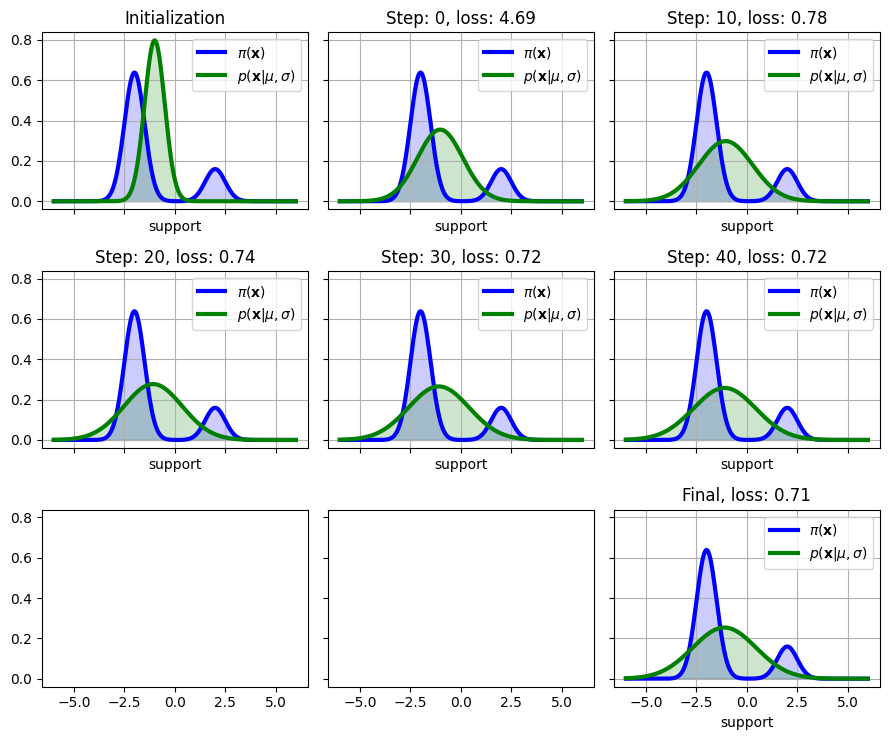

In [14]:
single_gaussian, optimizer = get_trainable_gaussian()

solve_task(optimizer, forward_KL_loss_fn, mixture_gaussian.log_prob, single_gaussian.log_prob, epochs=50)

Оптимизация reverse дивергенции.

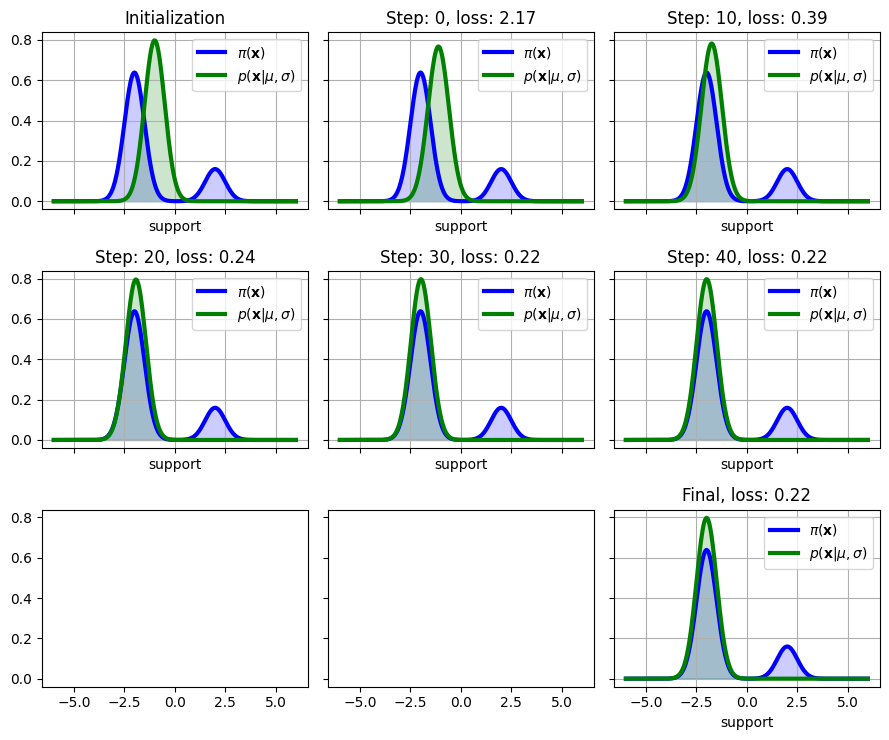

In [15]:
single_gaussian, optimizer = get_trainable_gaussian()

solve_task(optimizer, reverse_KL_loss_fn, mixture_gaussian.log_prob, single_gaussian.log_prob, epochs=50)

Исследуем, как ведет себя обучение в зависимости от разных иницилизаций. Наша цель - понять, как **mode-seeking** влияет на обучение.

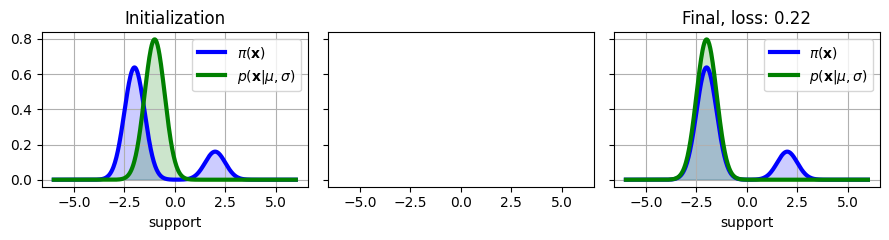

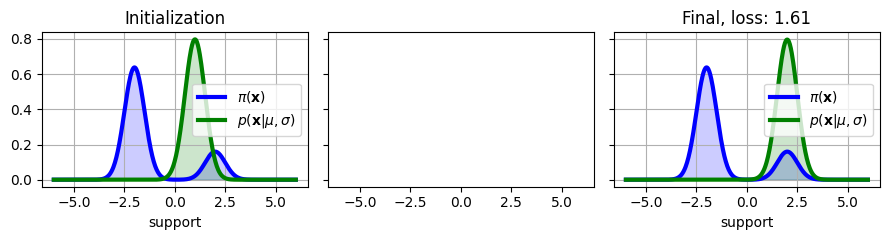

In [16]:
for mu in [-1.0, 1.0]:
    single_gaussian, optimizer = get_trainable_gaussian(mu=mu)
    solve_task(
        optimizer, reverse_KL_loss_fn, mixture_gaussian.log_prob, single_gaussian.log_prob,
        epochs=50, verbose=False
    )

<font color='Orange'>**Вопрос:**</font> Как проявляется mode-seeking? Приведите пример из жизни, например, если модель обучилась на датасете собак разных пород.

#### Ответ:

Мы не будем генерировать собак всех пород, скорее всего, будем генерировать собак только одной породы.

####
Важно понять, переносятся ли эффект **mode-seeking** на дивергенцию Йенсена &ndash; Шеннона, так как именно её мы оптимизируем в классических `GAN` моделях.

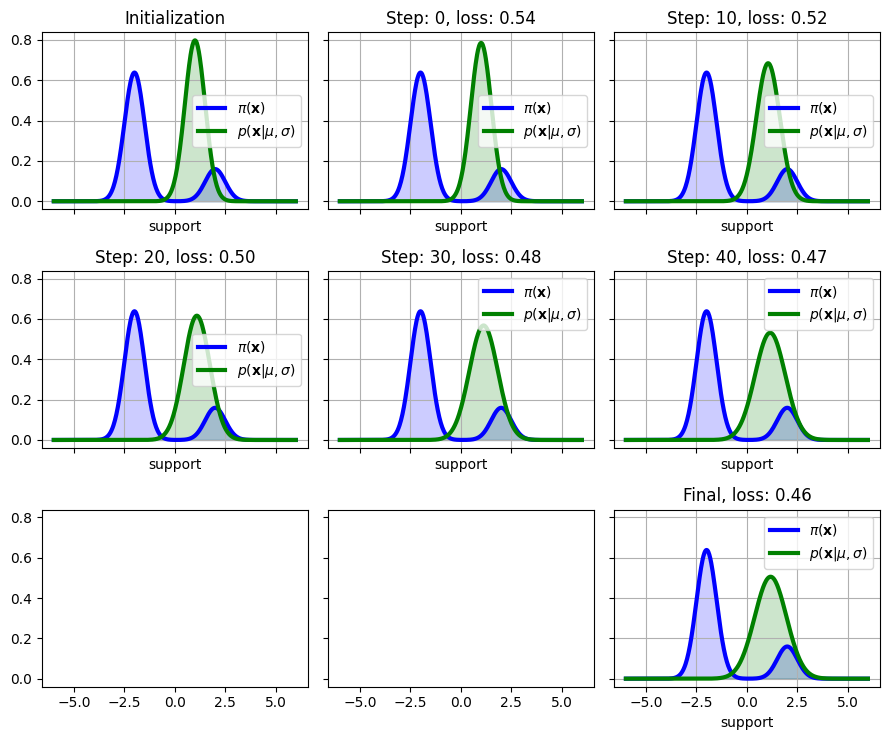

In [17]:
single_gaussian, optimizer = get_trainable_gaussian(mu=1.0)

solve_task(optimizer, JSD_loss_fn, mixture_gaussian.log_prob, single_gaussian.log_prob, epochs=50)

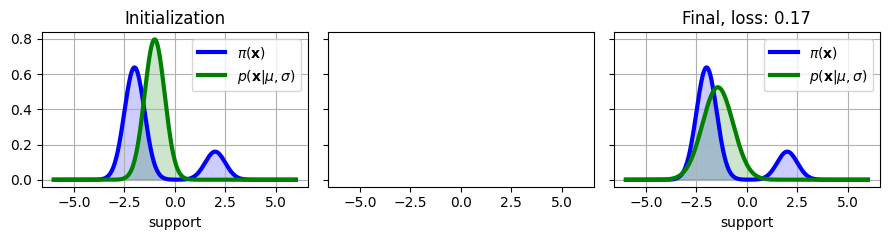

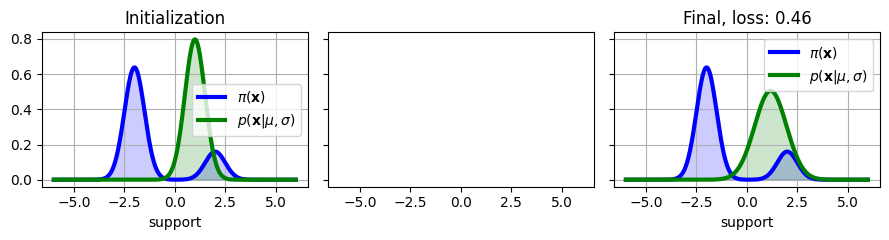

In [18]:
for mu in [-1.0, 1.0]:
    single_gaussian, optimizer = get_trainable_gaussian(mu=mu)
    solve_task(
        optimizer, JSD_loss_fn, mixture_gaussian.log_prob, single_gaussian.log_prob, epochs=50, verbose=False
    )

<font color='Orange'>**Вопрос:**</font> Что мы ожидаем при обучении GAN на дивергенцию  Йенсена &ndash; Шеннона?

#### Ответ:

Скорее всего, модель генератора будет сильно зависеть от инициализации. Кроме того, мы будем наблюдать коллапсирование мод.

## Обучение GAN на модельном примере

Посмотрим, как обучается `GAN` модели на модельном примере. Наша цель - рассмотреть, какие эффекты возникают при обучении: возникает ли колапсирование в моду (mode collapse), какие сэмплы получаются, как работает дискриминатор и как выглядит его предсказание.




<font color='Orange'>**Вопрос:**</font> Что должен выдавать идеальный дискриминатор, если генератор также обучен идеально?

#### Ответ:

Если генератор идеален, то вероятность отличить $\frac{1}{2}$.

In [19]:
def plot_gan_data(noise_fn, data_fn, data_pdf=None, samples=5000):
    noise = noise_fn(samples).numpy().flatten()
    target = data_fn(samples).numpy().flatten()

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))

    ax.hist(noise, label='noise', alpha=0.5, density=True, color='b')
    ax.hist(target, label='target', alpha=0.5, density=True, color='g')
    if data_pdf is not None:
        x = np.linspace(-6, 6, 100)
        ax.plot(x, data_pdf(x), 'g', label='real distribution')

    ax.grid(True)
    ax.legend(loc='upper left')

    fig.tight_layout()
    plt.show()

def plot_gan_loss(loss_g, loss_d_real, loss_d_fake):
    fig, ax = plt.subplots(1, 2, figsize=(9, 3))

    ax[0].plot(loss_g)

    ax[1].plot(loss_d_real, label="real")
    ax[1].plot(loss_d_fake, label="fake")
    ax[1].plot(loss_d_real + loss_d_fake, label="all")

    ax[1].legend()

    ax[0].grid(True)
    ax[1].grid(True)

    ax[0].set_title("Generator loss")
    ax[1].set_title("Discriminator loss")

    fig.tight_layout()
    plt.show()

@torch.no_grad()
def visualize_GAN(gan, data_pdf=None, ax=None):
    size = 500
    x = np.linspace(-6, 6, 100)
    bins = np.linspace(-6, 6, 60)

    real_data = gan.data_fn(size)
    noise = gan.noise_fn(size)
    sampled_data = gan.generate_samples(noise)
    d_probs = gan.D(torch.from_numpy(x).float().unsqueeze(-1))

    if ax is None:
        (fig, ax), show = plt.subplots(1, 1, figsize=(6, 4)), True
    else:
        show = False

    ax.plot(x, d_probs.numpy(), 'b', label='D distribution')

    ax.hist(noise.numpy(), label='noise', alpha=0.5, density=True, color='b', bins=bins)
    ax.hist(real_data.numpy(), label='real data', alpha=0.5, density=True, color='g', bins=bins)
    ax.hist(sampled_data.numpy(), label='G samples', alpha=0.5, density=True, color='r', bins=bins)

    if data_pdf is not None:
        ax.plot(x, data_pdf(x), 'g', label='real distribution')

    ax.grid(True)
    ax.legend(loc='upper left')

    if show:
        fig.tight_layout()
        plt.show()

Напишем класс, который будет содержать в себе логику обучения GAN.

In [20]:
class VanillaGAN(torch.nn.Module):
    def __init__(
        self, G, D, noise_fn, data_fn, batch_size, lr_G=2e-4, lr_D=1e-3
    ):
        """A GAN class for holding and training a generator and discriminator
        Args:
            G: a Generator network
            D: A Discriminator network
            noise_fn: function f(num: int) -> pytorch tensor, (latent vectors)
            data_fn: function f(num: int) -> pytorch tensor, (real samples)
            batch_size: batch size for training
            lr_G: learning rate for the generator
            lr_D: learning rate for the discriminator
        """
        super().__init__()

        self.G = G
        self.D = D

        self.noise_fn = noise_fn
        self.data_fn = data_fn

        self.batch_size = batch_size

        self.criterion = torch.nn.BCELoss()

        self.optim_G = torch.optim.Adam(
            G.parameters(), lr=lr_G, betas=(0.5, 0.999)
        )
        self.optim_D = torch.optim.Adam(
            D.parameters(), lr=lr_D, betas=(0.5, 0.999)
        )

        self.register_buffer(
            'target_zeros', torch.zeros((self.batch_size, 1), dtype=torch.float32), persistent=False
        )
        self.register_buffer(
            'target_ones', torch.ones((self.batch_size, 1), dtype=torch.float32), persistent=False
        )

    @torch.no_grad()
    def generate_samples(self, latents=None, n=None):
        """Sample from the generator.
        Args:
            latents: A pytorch latent vector
            n: number of generated samples
        vectors.
        ! We don't need grad for generated samples
        """

        if latents is None:
            latents = self.noise_fn(self.batch_size if n is None else n)
        else:
            assert n is None

        return self.G(latents)

    def train_step_G(self):
        """Train the generator one step and return the loss."""
        self.optim_G.zero_grad()

        latents = self.noise_fn(self.batch_size)

        generated = self.G(latents)
        classifications = self.D(generated)

        loss = self.criterion(classifications, self.target_ones)
        loss.backward()

        self.optim_G.step()

        return loss.item()

    def train_step_D(self):
        """Train the discriminator one step and return the losses."""
        self.optim_D.zero_grad()

        # Compute loss for samples from data distribution
        real_samples = self.data_fn(self.batch_size)
        pred_real = self.D(real_samples)
        loss_real = self.criterion(pred_real, self.target_ones)

        # Compute loss for fake samples
        latents = self.noise_fn(self.batch_size)

        fake_samples = self.generate_samples(latents)
        pred_fake = self.D(fake_samples)
        loss_fake = self.criterion(pred_fake, self.target_zeros)

        # Combine losses
        loss = (loss_real + loss_fake) / 2
        loss.backward()

        self.optim_D.step()

        return loss_real.item(), loss_fake.item()

Так как у нас модельный пример, то в качестве архитектур генеретора и дискриминатора мы будем рассматривать полносвязанные сети.

In [21]:
def get_simple_model(hidden_sizes):
    assert len(hidden_sizes) > 1

    network = torch.nn.Sequential()
    for in_features, out_features in zip(hidden_sizes[:-2], hidden_sizes[1:-1]):
        network.append(torch.nn.Linear(in_features, out_features))
        network.append(torch.nn.ReLU())

    network.append(torch.nn.Linear(hidden_sizes[-2], hidden_sizes[-1]))

    return network

Генератор принимает на вход случайные числа из диапозона $[-0.5, 0.5]$.

In [22]:
def noise_fn(x):
    return torch.rand((x, 1)) - 0.5

В качестве распределения данных мы будем также использовать смесь распределений. Кроме того, в этом примере мы будем считать правдоподобие сгенерированных данных, на практике в реальных задачах это почти всегда невозможно.

In [23]:
mixture_gaussian = torch.distributions.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([0.7, 0.3])),
    torch.distributions.Normal(
        loc=torch.tensor([-3., 3.]),
        scale=torch.tensor([1., 1.])
    )
)

def data_fn(x):
    return mixture_gaussian.sample((x, 1))

def data_pdf(x):
    return mixture_gaussian.log_prob(torch.tensor(x)).exp().numpy()

Собирём всё вместе.

In [24]:
def get_GAN(G_hidden_sizes=(1, 64, 64, 64, 1), D_hidden_sizes=(1, 64, 64, 64, 1)):
    G = get_simple_model(G_hidden_sizes)
    D = get_simple_model(D_hidden_sizes).append(torch.nn.Sigmoid())

    gan = VanillaGAN(G, D, noise_fn, data_fn, batch_size=32)

    return gan

Мы будем визуализировать:

- Шум, который подали в генератор;
- Распределение данных;
- Датасет (сэмплы из расределения данных);
- Сэмплы, которые сгенерировал генератор;
- Выходы дискриминатора (распределение дискриминатора);

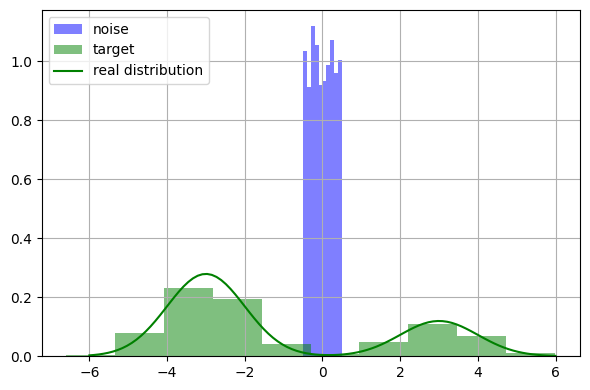

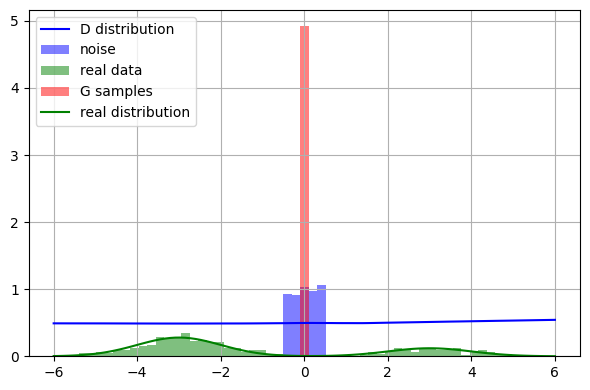

In [25]:
gan = get_GAN()

plot_gan_data(noise_fn, data_fn, data_pdf)
visualize_GAN(gan, data_pdf=data_pdf)

Напишем цикл обучения. Обратите внимание, что благодаря классу VanillaGAN цикл обучения выглядит очень похоже на цикл обучения обычного классификатора.

In [26]:
def train_1D_GAN(gan, n_batches=100, epochs=50, n_D_steps_per_G=1):
    def is_logging_epoch(epoch):
        return (epoch % 10 == 0 or epoch == epochs - 1)

    start_time = time.time()

    loss_g, loss_d_real, loss_d_fake = [], [], []
    for epoch in range(epochs):
        loss_g_running, loss_d_real_running, loss_d_fake_running = 0.0, 0.0, 0.0

        if is_logging_epoch(epoch):
            fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)

        for idx in range(n_batches):
            if idx == 0 and is_logging_epoch(epoch):
                axes[0].set_title('Train D for one batch: start')
                visualize_GAN(gan, data_pdf=data_pdf, ax=axes[0])

            for _ in range(n_D_steps_per_G):
                loss_D_real_batch, loss_D_fake_batch = gan.train_step_D()
                loss_d_real_running += loss_D_real_batch
                loss_d_fake_running += loss_D_fake_batch

            if idx == 0 and is_logging_epoch(epoch):
                axes[1].set_title('Train D for one batch: end')
                visualize_GAN(gan, data_pdf=data_pdf, ax=axes[1])

            loss_G_batch = gan.train_step_G()
            loss_g_running += loss_G_batch

        loss_g.append(loss_g_running / n_batches)
        loss_d_real.append(loss_d_real_running / (n_batches * n_D_steps_per_G))
        loss_d_fake.append(loss_d_fake_running / (n_batches * n_D_steps_per_G))

        if is_logging_epoch(epoch):
            fig.suptitle(
                "Epoch {0}/{1} ({2:.1f}s): G={3:.3f}, Dr={4:.3f}, Df={5:.3f}".format(
                    epoch + 1, epochs, time.time() - start_time,
                    loss_g[-1], loss_d_real[-1], loss_d_fake[-1]
                )
            )
            axes[2].set_title('After epoch')
            visualize_GAN(gan, data_pdf=data_pdf, ax=axes[2])

            fig.tight_layout()
            plt.show()

    return np.array(loss_g), np.array(loss_d_real), np.array(loss_d_fake)

Обучим модель и зафиксируем генераторы случайных чисел, так как нам важна воспроизводимость результатов. Будем обучать генератор каждую итерацию.



<font color='Orange'>**Вопрос:**</font> Почему обучать генератор каждую итерацию плохо?

#### Ответ:

Для обучение генератора требуется идеальный дискриминатор.

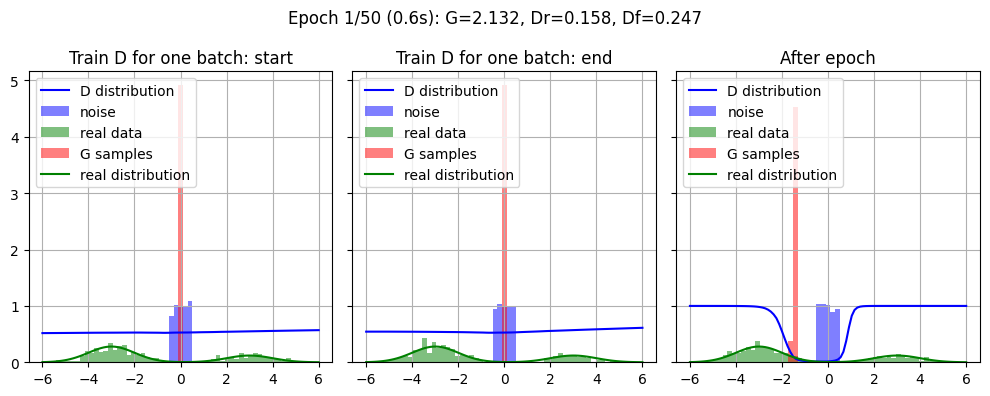

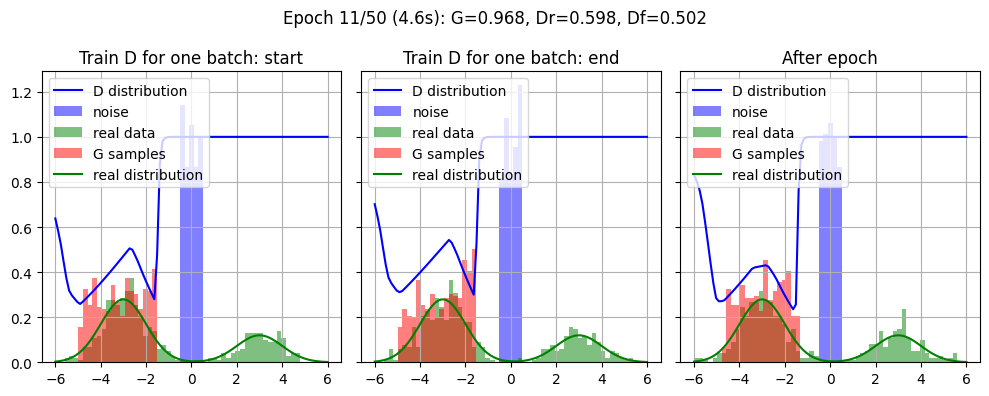

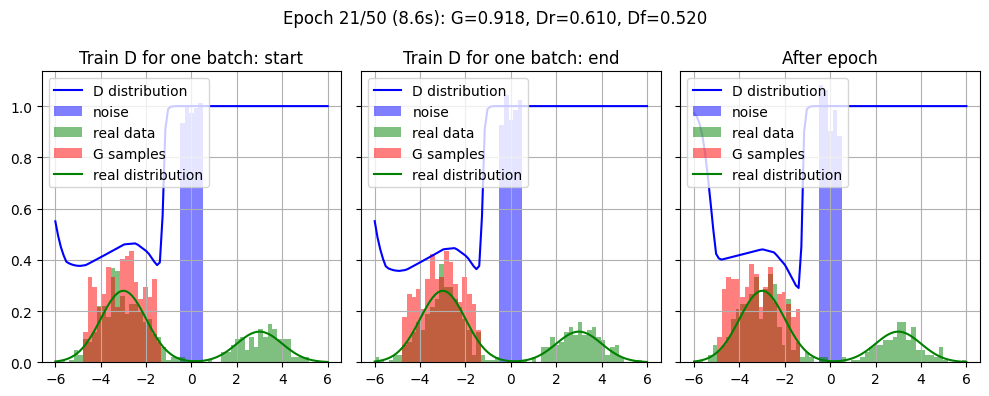

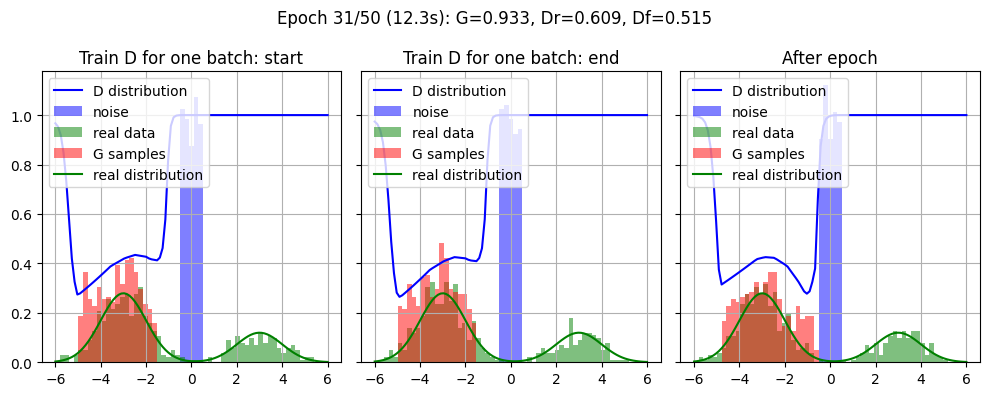

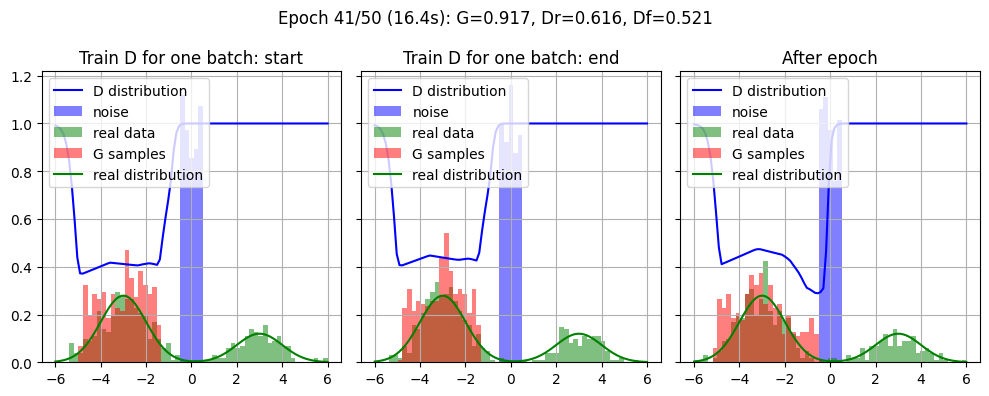

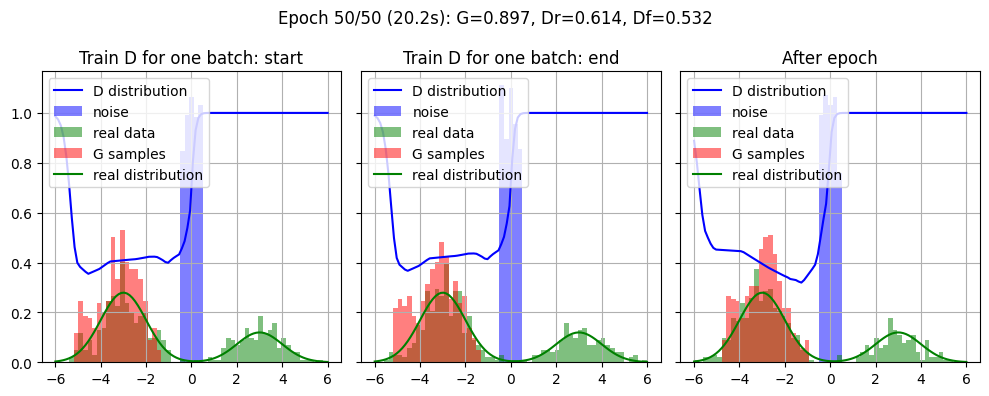

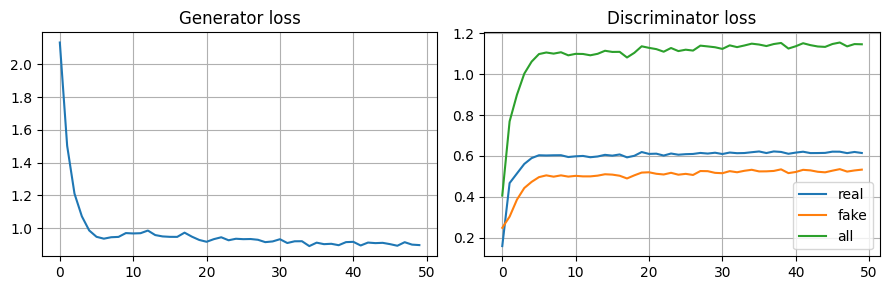

In [27]:
set_global_seed(0)

gan = get_GAN()
loss_g_1, loss_d_real_1, loss_d_fake_1 = train_1D_GAN(gan)
plot_gan_loss(loss_g_1, loss_d_real_1, loss_d_fake_1)

В итоге мы получили коллапсирование в левую моду. Обучим модель ещё раз при других инициализациях моделей.

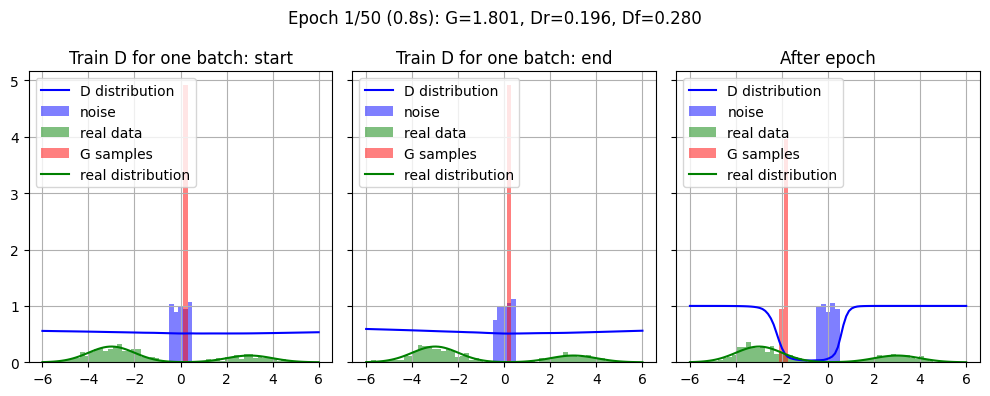

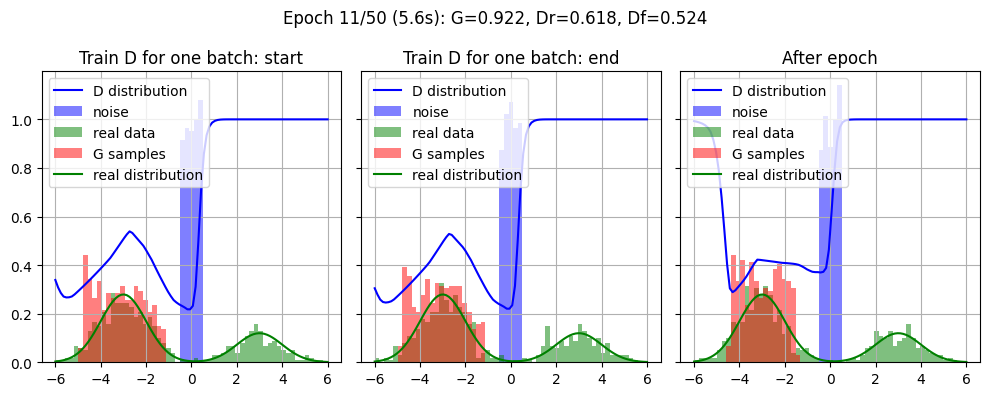

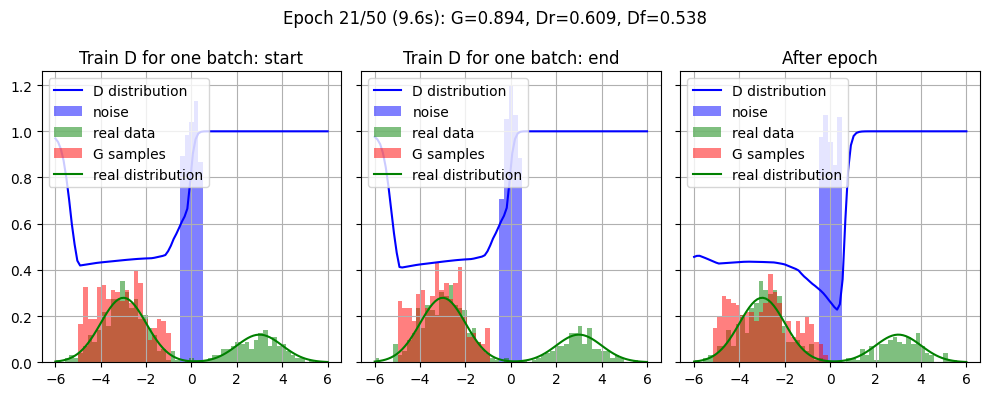

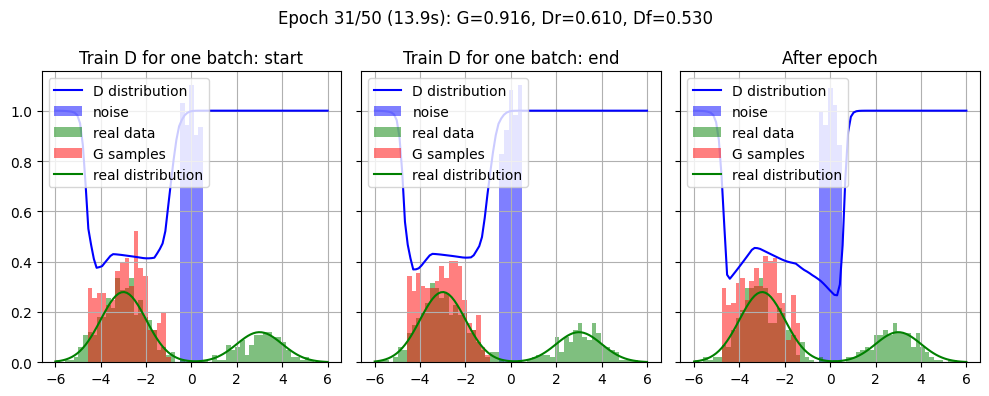

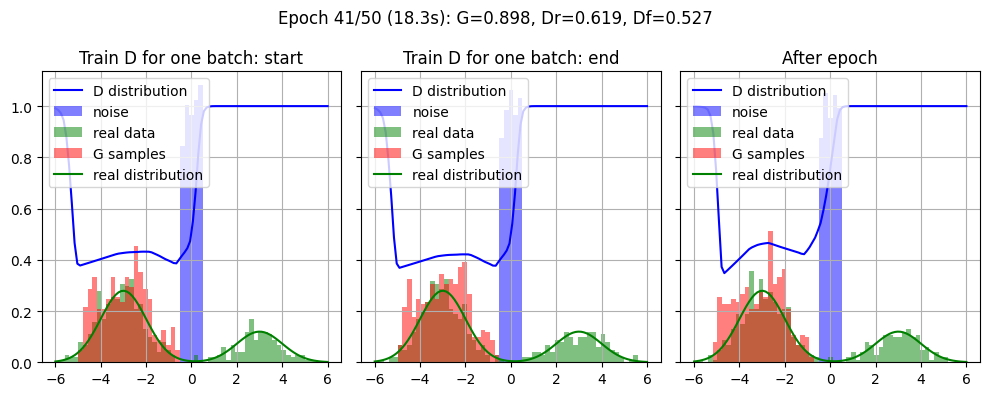

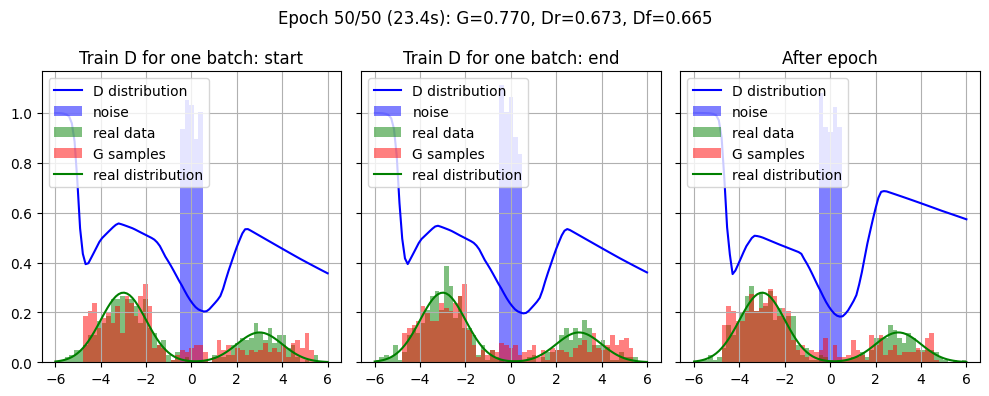

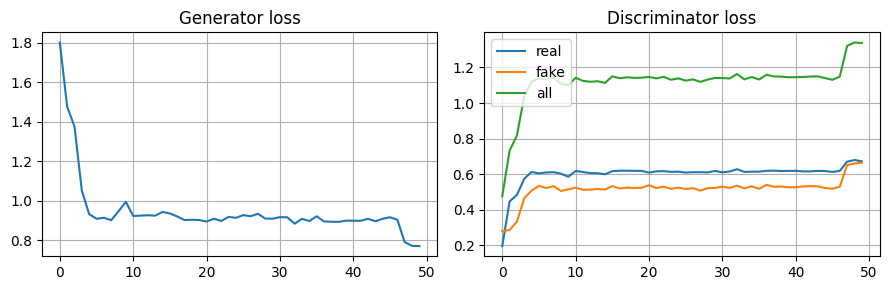

In [28]:
set_global_seed(3)

gan = get_GAN()
loss_g_1, loss_d_real_1, loss_d_fake_1 = train_1D_GAN(gan)
plot_gan_loss(loss_g_1, loss_d_real_1, loss_d_fake_1)

В конце у нас получилось засэмплировать из обеих мод, то есть модель обучилась хорошо. Попробуем теперь обучить модель, но обновлять генератор каждые 20 итераций обучений.

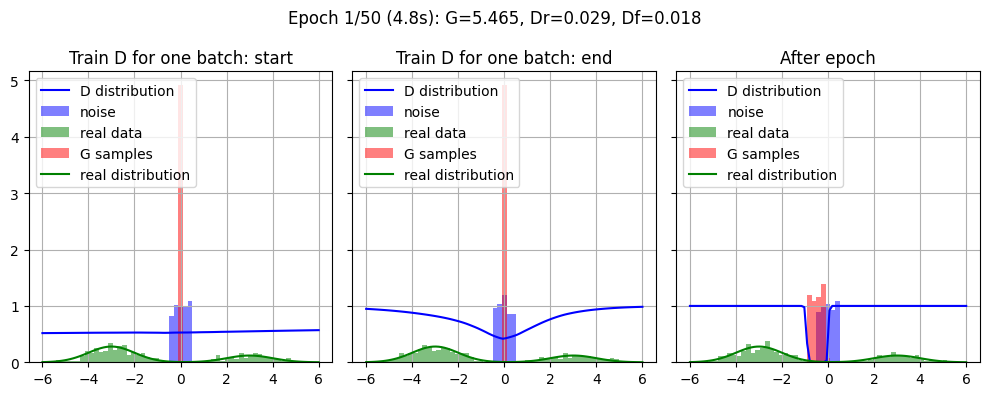

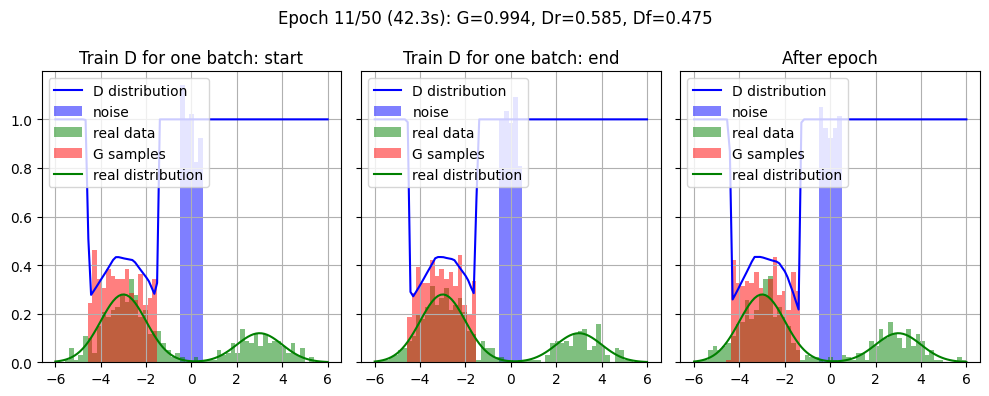

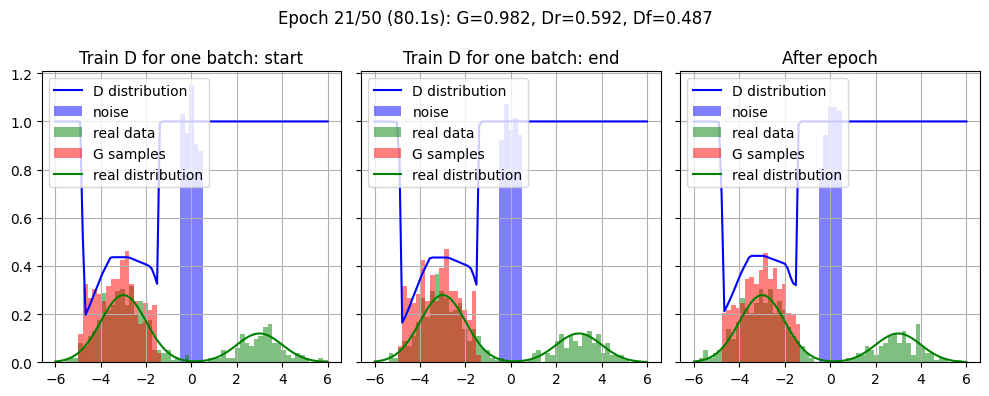

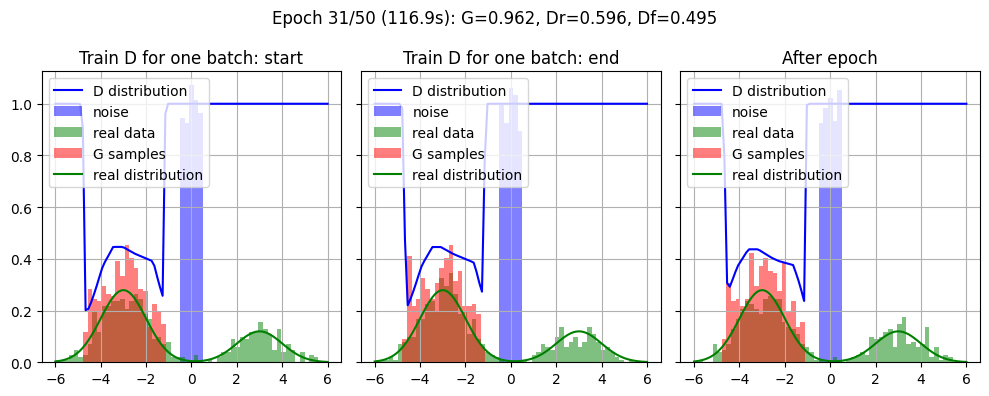

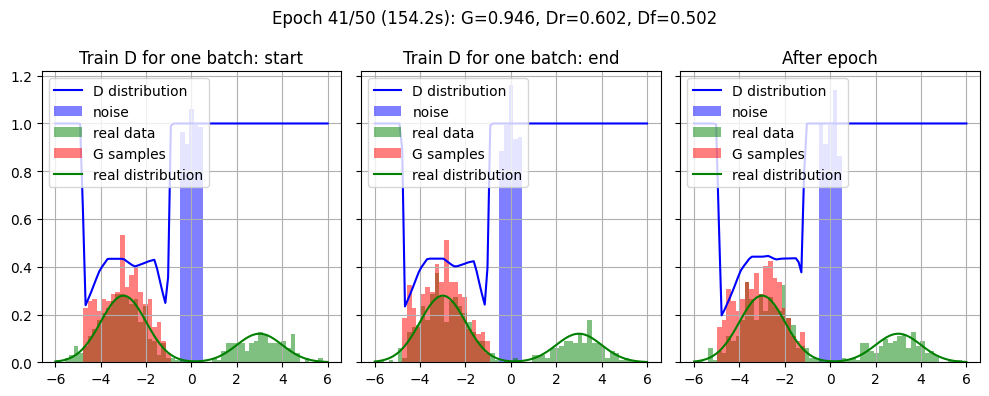

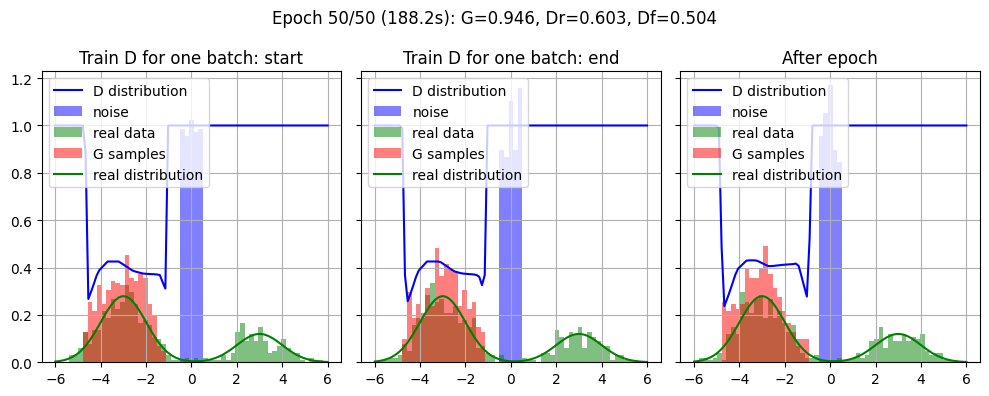

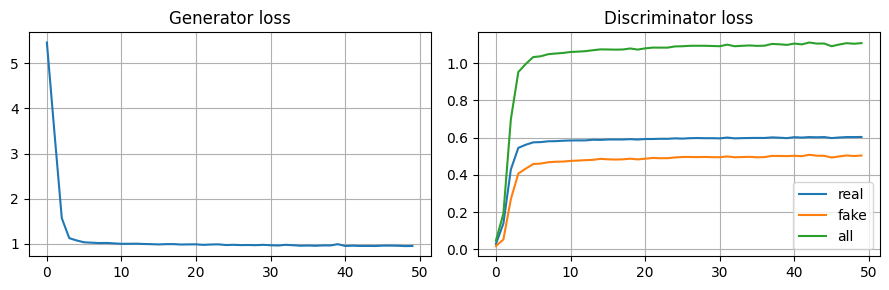

In [29]:
set_global_seed(0)

gan = get_GAN()
loss_g_20, loss_d_real_20, loss_d_fake_20 = train_1D_GAN(gan, n_D_steps_per_G=20)
plot_gan_loss(loss_g_20, loss_d_real_20, loss_d_fake_20)

Выше мы нашли инициализацию, при которой GAN обучается хорошо. Воспользуемся ей, для этого используем те же самые генераторы случайных чисел. Только теперь будем обучать генератор раз в 20 итераций.

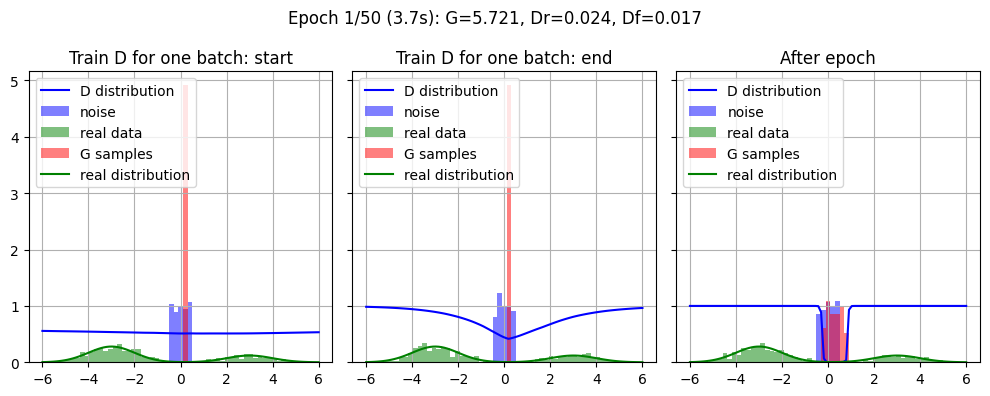

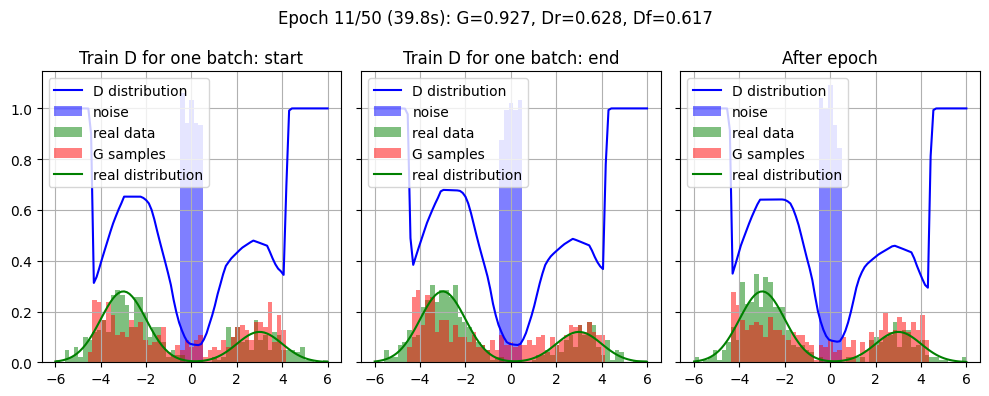

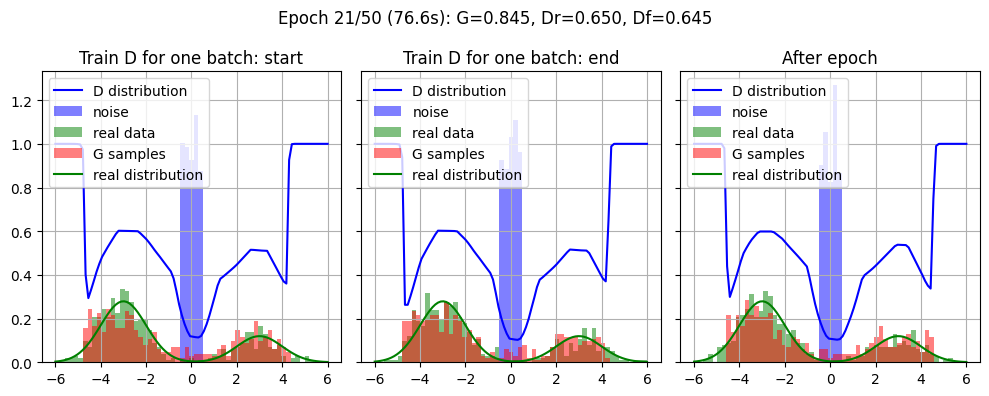

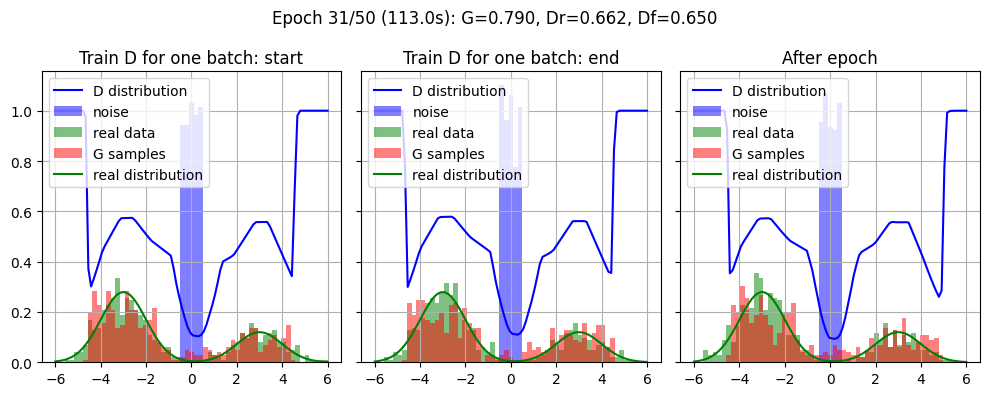

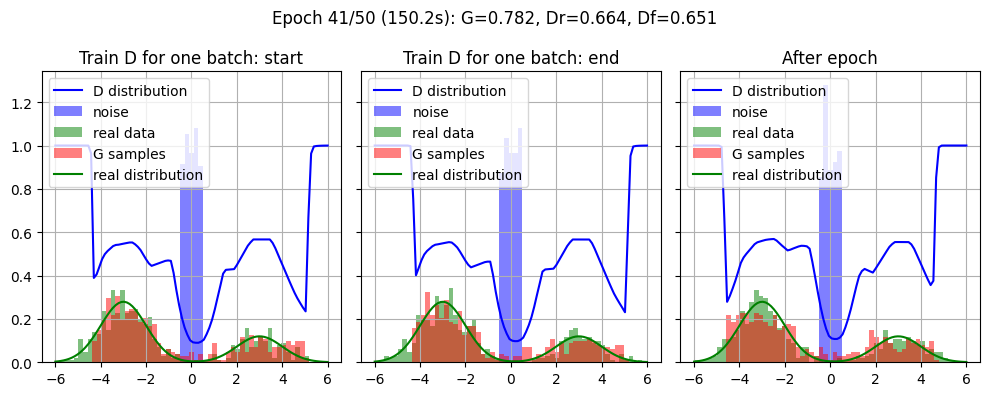

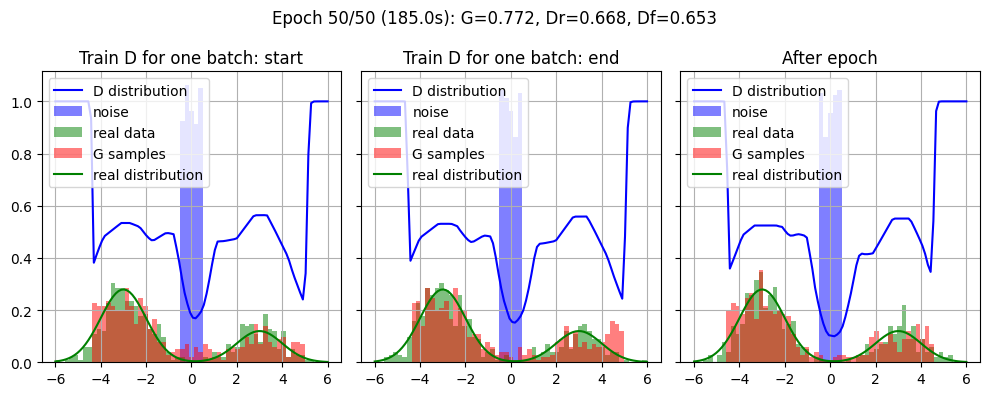

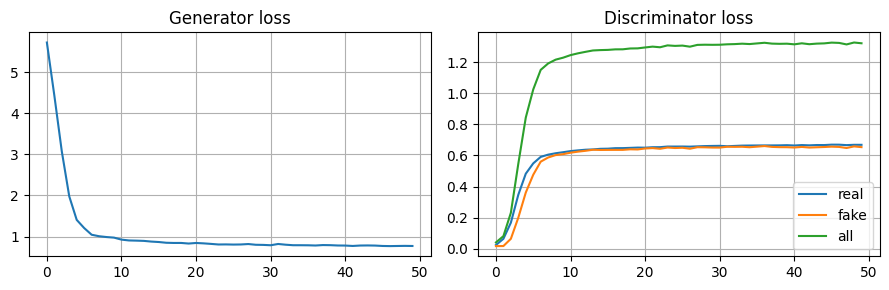

In [30]:
set_global_seed(3)

gan = get_GAN()
loss_g_20, loss_d_real_20, loss_d_fake_20 = train_1D_GAN(gan, n_D_steps_per_G=20)
plot_gan_loss(loss_g_20, loss_d_real_20, loss_d_fake_20)

Мы видим, что получилось обучить генератор уже на 11 эпохе, когда до этого на той же иницилазации мы обучились примерно на 47 эпохе. Мы получаем, что частота обновления генератора очень важна для стабильного и хорошего обучения GAN моделей.

<font color='Orange'>**Вопрос:**</font>  Как эти результаты связаны с теорией? Зачем обучать дискриминатор несколько итераций подряд?

#### Ответ:

Коллапсирование мод и влияние качества дискриминатора на обучение

## Проблемы GAN

Как мы видели выше, чаще всего мы получаем данные из одной моды, что является следствием нашего функционала. После чего возникает вопрос: "Действительно ли GAN модели обучаемые и могут хорошо работать?"

К счатью, обучить GAN можно, но, правда, крайне сложно.

Ниже представлены примеры сгенерированных изображений из оригинальной статьи (2014 год):

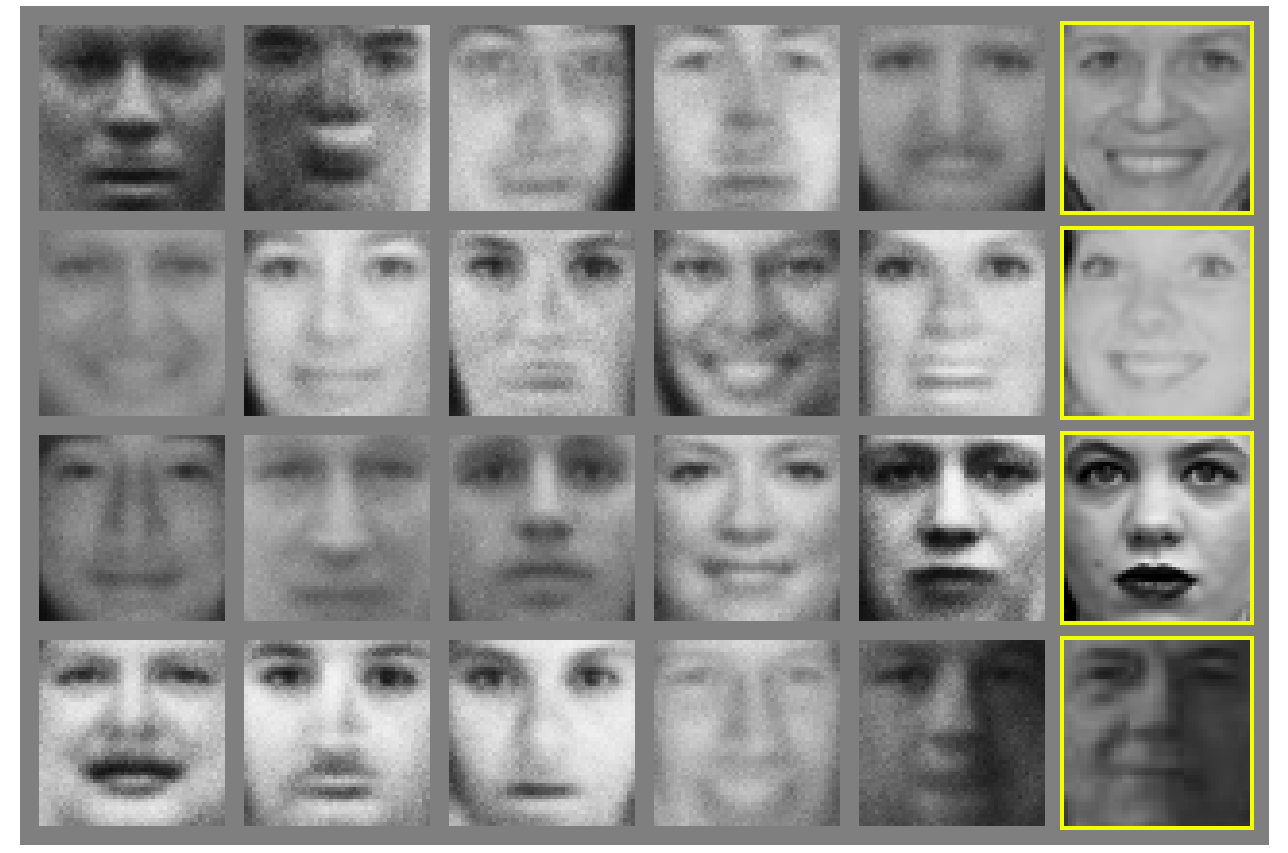

[Источник](https://arxiv.org/abs/1406.2661)

Сравним с результатами генерации [DCGAN](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html) из 2016 года:

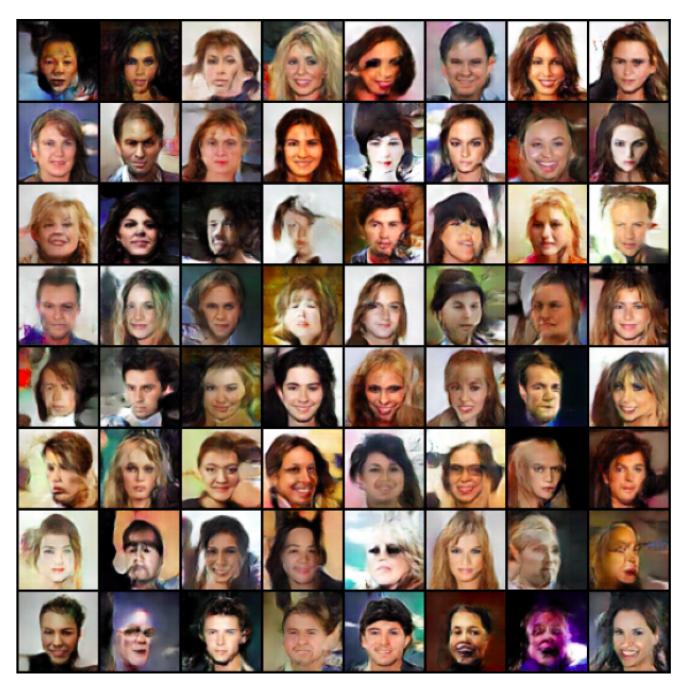

[Источник](https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html)

Прошло 2 года, при этом качество генерации заметно возросло (переход от черно-белых изображений к цветным крайне сложный).Что же поменялось за это время?

1) Люди перешли к сверточным нейронным сетям и стали использовать модели с большим числом параметров;

2) Научились правильнее настраивать параметры модели и архитектуры.

Но самое важное, придумали кучу разных трюков, как учить GAN. [Примеры, обязательные к прочтению](https://github.com/soumith/ganhacks), [а также менее обязательные к прочтению](https://arxiv.org/pdf/1701.04862.pdf)

Примеры основных трюков:
- Нормализация входа;
- Сэмплировать шум $z$ для генератора не равномерным, а из сферы (нормальный);
- Использовать SGD для дискриминатора и Adam для генератора (для новых моделей не актуально);
- Избегать MaxPool, использовать stride свертки;
- Использовать replay buffer (сохранять сгенерированные изображения в буффер и использовать для обучения дискриминатора в будущем);
- Зашумлять входы в дискриминатор;
- Всегда использовать Dropout в генераторе (в eval и train режимах);
- И ещё много всего...

## WGAN практика MNIST


Мы будем реализовать Wasserstein GAN с gradient penalty, так как благодаря нему модель лучше учится и градиенты меньше затухают.

Реализация взята из [GitHub](https://github.com/eriklindernoren/PyTorch-GAN), в котором реализован зоопарк GAN моделей.

### WGAN



[WGAN](https://arxiv.org/abs/1701.07875) модель использует клиппинг весов для достижения Липшицевости функции критика.

Функция потерь
$$
\min_{G} W(\pi || p) \approx \min_{G} \max_{\boldsymbol{\phi} \in \boldsymbol{\Phi}} \left[ \mathbb{E}_{\pi(\mathbf{x})} f(\mathbf{x}, \boldsymbol{\phi})  - \mathbb{E}_{p(\mathbf{z})} f(G(\mathbf{z}, \boldsymbol{\theta}), \boldsymbol{\phi} )\right].
$$

Здесь $f(\mathbf{x}, \boldsymbol{\phi})$ модель критика. Веса критика $\boldsymbol{\phi}$ должны принадлежать компакту $\boldsymbol{\Phi} = [-c, c]^d$.

## WGAN-GP

[WGAN-GP](https://arxiv.org/pdf/1704.00028.pdf) модель использует gradient penalty для достижения Липшицевости функции критика.

Функция потерь
$$
    W(\pi || p) = \underbrace{\mathbb{E}_{\pi(\mathbf{x})} f(\mathbf{x})  - \mathbb{E}_{p(\mathbf{x} | \boldsymbol{\theta})} f(\mathbf{x})}_{\text{original critic loss}} + \lambda \underbrace{\mathbb{E}_{U[0, 1]} \left[ \left( \| \nabla_{\hat{\mathbf{x}}} f(\hat{\mathbf{x}}) \|_2 - 1 \right) ^ 2\right]}_{\text{gradient penalty}},
$$
где сэмплы $\hat{\mathbf{x}}_t = t \mathbf{x} + (1 - t) \mathbf{y}$ с $t \in [0, 1]$ равномерно засэмплированы вдоль прямой соединяющей точки: $\mathbf{x}$ из распределения данных $\pi(\mathbf{x})$ и $\mathbf{y}$ распределения генератора $p(\mathbf{x} \mid \boldsymbol{\theta})$.

## Основные параметры

Обновлять дискриминатор мы будем каждый шаг, а генератор каждый пятый шаг. Такой выбор проверен на практике и обусловлен эмпирическим опытом.

Создадим удобный конфиг для гиперпараметров с помощью ml-collections.

In [31]:
opt = ConfigDict()

# обучение
opt.n_epochs = 200
opt.batch_size = 64

# оптимизатор
opt.lr = 0.0002
opt.beta1 = 0.5
opt.beta2 = 0.999

# модель
opt.latent_dim = 100
opt.img_size = 28
opt.channels = 1
opt.img_shape = (opt.channels, opt.img_size, opt.img_size)

# обучение GAN
opt.lambda_gp = 10
opt.n_critic = 5
opt.clip_value = 0.01
opt.sample_interval = 2000

opt

batch_size: 64
beta1: 0.5
beta2: 0.999
channels: 1
clip_value: 0.01
img_shape: !!python/tuple
- 1
- 28
- 28
img_size: 28
lambda_gp: 10
latent_dim: 100
lr: 0.0002
n_critic: 5
n_epochs: 200
sample_interval: 2000

In [32]:
device = torch.device('cuda', 0) if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda', index=0)

Обучать будем на MNIST, так как цветные и более сложные изображения требуют больших ресурсов и времени.

In [ ]:
path = './data/mnist'
os.makedirs(path, exist_ok=True)

forward_transform = transforms.Compose([
    transforms.Resize(opt.img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

inverse_transform = transforms.Compose([
    transforms.Normalize([0.0], [2.0]),
    transforms.Normalize([-0.5], [1.0]),
    transforms.ToPILImage()
])

dataset = MNIST(path, train=True, download=True, transform=forward_transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=opt.batch_size, shuffle=True)

### Генератор

Для генератора мы будем брать свёрточную архитектуру.

In [ ]:
class Generator(torch.nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        def block(in_feat, out_feat, normalize=True):
            layers = [torch.nn.Linear(in_feat, out_feat)]
            if normalize:
                layers += [torch.nn.BatchNorm1d(out_feat, 0.8)]
            layers += [torch.nn.LeakyReLU(0.2, inplace=True)]
            return layers

        self.model = torch.nn.Sequential(
            *block(config.latent_dim, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            torch.nn.Linear(1024, int(np.prod(config.img_shape))),
            torch.nn.Tanh()
        )

    def forward(self, z):
        images = self.model(z)
        images = images.view(images.shape[0], *self.config.img_shape)

        return images

### Дискриминатор (критик)

Если дискриминатор будет крайне эффективным и мощным, то генератор не обучится. Поэтому мы возьмем простую полносвязанную архитектуру.

In [ ]:
class Discriminator(torch.nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.model = torch.nn.Sequential(
            torch.nn.Linear(np.prod(self.config.img_shape), 512),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Linear(512, 256),
            torch.nn.LeakyReLU(0.2, inplace=True),
            torch.nn.Linear(256, 1),
        )

    def forward(self, image):
        image = image.flatten(start_dim=1)
        logits = self.model(image)

        return logits

### Создание моделей

In [ ]:
# Initialize generator and discriminator
generator = Generator(config=opt).to(device)
discriminator = Discriminator(config=opt).to(device)

# Optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=opt.lr, betas=(opt.beta1, opt.beta2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=opt.lr, betas=(opt.beta1, opt.beta2))

In [ ]:
generator, discriminator

### Gradient penalty

\begin{align}
\text{GP}(f) = \mathbb{E}_{U[0, 1]} \left[ \left( \| \nabla_{\hat{\mathbf{x}}} f(\hat{\mathbf{x}}) \|_2 - 1 \right) ^ 2\right],
\end{align}
где сэмплы $\hat{\mathbf{x}}_t = t \mathbf{x} + (1 - t) \mathbf{y}$ с $t \in [0, 1]$ равномерно засэмплированы вдоль прямой соединяющей точки: $\mathbf{x}$ из распределения данных $\pi(\mathbf{x})$ и $\mathbf{y}$ распределения генератора $p(\mathbf{y} \mid \boldsymbol{\theta})$.

In [ ]:
def compute_gradient_penalty(D, real_samples, fake_samples):
    """Calculates the gradient penalty loss for WGAN GP"""

    # Random weight term for interpolation between real and fake samples
    alpha = torch.rand((real_samples.size(0), 1, 1, 1), device=real_samples.device)

    # Get random interpolation between real and fake samples
    interpolates = torch.lerp(real_samples, fake_samples, alpha).requires_grad_(True)
    logits = D(interpolates)

    fake = torch.ones((real_samples.shape[0], 1), device=real_samples.device, requires_grad=False)

    # Get gradient w.r.t. interpolates
    gradients = torch.autograd.grad(
        outputs=logits,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True, retain_graph=True
    )[0]

    gradients = gradients.flatten(start_dim=1)
    gradient_penalty = torch.mean(
        torch.square(
            torch.linalg.norm(gradients, dim=1) - 1.0
        )
    )

    return gradient_penalty

Посмотреть результат обучения можно [по ссылке на wandb]().

In [ ]:
# ----------
#  Training
# ----------

wandb.init(
    project='mmp_WGAN-GP_2025',
    save_code=True,
    name='WGAN-GP-MNIST'
)

batches_done = 0
try:
    for epoch in range(opt.n_epochs):
        for idx, (real_images, _) in enumerate(dataloader):
            real_images = real_images.to(device)

            # ---------------------
            #  Train Discriminator
            # ---------------------

            optimizer_D.zero_grad()

            # Sample noise as generator input
            z = torch.randn((real_images.shape[0], opt.latent_dim), device=device)

            # Generate a batch of images
            fake_images = generator(z)

            # Real images
            real_logits = discriminator(real_images)
            # Fake images
            fake_logits = discriminator(fake_images)
            # Gradient penalty
            gradient_penalty = compute_gradient_penalty(discriminator, real_images.detach(), fake_images.detach())
            # Adversarial loss
            d_loss = -torch.mean(real_logits) + torch.mean(fake_logits) + opt.lambda_gp * gradient_penalty

            d_loss.backward()
            optimizer_D.step()

            # -----------------
            #  Train Generator
            # -----------------

            # Train the generator every n_critic steps
            if idx % opt.n_critic == 0:
                optimizer_G.zero_grad()

                # Generate a batch of images
                fake_images = generator(z)

                # Loss measures generator's ability to fool the discriminator
                # Train on fake images
                fake_logits = discriminator(fake_images)
                g_loss = -torch.mean(fake_logits)

                g_loss.backward()
                optimizer_G.step()

                wandb.log(
                    {'G_loss': g_loss.item(), 'D_loss':  d_loss.item(), 'Penalty': gradient_penalty.item()},
                    step=batches_done
                )

                if batches_done % opt.sample_interval == 0:
                    fake_grid = transforms.functional.to_pil_image(
                        make_grid(fake_images, nrow=8, padding=0)
                    )
                    real_grid = inverse_transform(make_grid(real_images, nrow=8, padding=0))

                    wandb.log({"Fake images": wandb.Image(fake_grid)}, step=batches_done)
                    wandb.log({"Real images": wandb.Image(real_grid)}, step=batches_done)

                batches_done += opt.n_critic
except KeyboardInterrupt:
    pass

wandb.finish()

In [ ]:
torch.save({
        "generator": generator.state_dict(),
        "discriminator": discriminator.state_dict()
    }, "checkpoint.pth"
)